# 📊 Predictive Churn Analysis

### Customer Churn Prediction using Machine Learning

**Project Objective:**  
To predict whether a customer is likely to churn using Machine Learning.

### Project Workflow
1. Data Loading
2. Data Preprocessing
3. One-Hot Encoding
4. MinMax Scaling
5. Train-Test Split
6. Logistic Regression
7. Model Evaluation
8. Churn Probability Prediction
9. High-Risk Customer Identification

### Technologies Used
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Google Colab

### Model Used
**Logistic Regression**




## 1. Import Required Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_model_v2.csv to customer_churn_model_v2.csv


### Load the CSV Dataset

In [2]:
import pandas as pd

df = pd.read_csv("customer_churn_model_v2.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (800, 13)


,CustomerID,Age,Region,TenureMonths,SubscriptionType,MonthlyChargesINR,TotalChargesINR,ContractType,SupportTickets,LatePayments,PaymentMethod,AutoPay,Churn
0,CUST-100001,57,South,33,Standard,767.25,23893.97,Month-to-Month,4,1,UPI,Yes,Yes
1,CUST-100002,44,South,45,Basic,476.72,21627.46,Two Year,0,1,UPI,Yes,Yes
2,CUST-100003,64,South,57,Basic,414.81,22500.07,One Year,1,1,UPI,No,Yes
3,CUST-100004,57,East,44,Pro,1171.76,50309.16,Month-to-Month,4,0,Card,Yes,Yes
4,CUST-100005,58,North,49,Pro,1130.19,55980.21,Month-to-Month,3,0,Wallet,No,No


## 3. Data Understanding

In [34]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         800 non-null    object 
 1   Age                800 non-null    int64  
 2   Region             800 non-null    object 
 3   TenureMonths       800 non-null    int64  
 4   SubscriptionType   800 non-null    object 
 5   MonthlyChargesINR  800 non-null    float64
 6   TotalChargesINR    800 non-null    float64
 7   ContractType       800 non-null    object 
 8   SupportTickets     800 non-null    int64  
 9   LatePayments       800 non-null    int64  
 10  PaymentMethod      800 non-null    object 
 11  AutoPay            800 non-null    object 
 12  Churn              800 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 81.4+ KB


### Check Missing Values

In [3]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Region,0
TenureMonths,0
SubscriptionType,0
MonthlyChargesINR,0
TotalChargesINR,0
ContractType,0
SupportTickets,0
LatePayments,0


### Churn Distribution

In [5]:
df["Churn"].value_counts()

,count
Churn,
No,466
Yes,334


In [7]:
df.columns

Index(['CustomerID', 'Age', 'Region', 'TenureMonths', 'SubscriptionType',
       'MonthlyChargesINR', 'TotalChargesINR', 'ContractType',
       'SupportTickets', 'LatePayments', 'PaymentMethod', 'AutoPay', 'Churn'],
      dtype='object')

## 4. Feature and Target Separation

In [8]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (800, 12)
y shape: (800,)


### Encode Churn Target

In [9]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())

Churn
0    466
1    334
Name: count, dtype: int64


### Identify Categorical and Numerical Columns

In [10]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))

Categorical columns: ['CustomerID', 'Region', 'SubscriptionType', 'ContractType', 'PaymentMethod', 'AutoPay']
Numeric columns: ['Age', 'TenureMonths', 'MonthlyChargesINR', 'TotalChargesINR', 'SupportTickets', 'LatePayments']


## 5. Data Preprocessing
### One-Hot Encoding and MinMax Scaling

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", MinMaxScaler(), numeric_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Processed X shape:", X_processed.shape)

Processed X shape: (800, 823)


## 6. Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (640, 823)
Testing data: (160, 823)


## 7. Logistic Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


### Generate Churn Predictions

In [17]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1]


## 8. Model Evaluation

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.6375
Precision: 0.5738
Recall   : 0.5224
F1-Score : 0.5469


### ROC-AUC Score

In [19]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.6816


## 9. Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67 26]
 [32 35]]


### Confusion Matrix Visualization

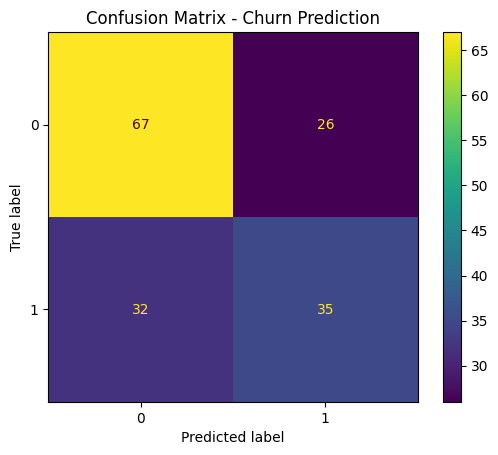

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Churn Prediction")
plt.show()

## 10. Churn Probability Prediction

In [22]:
churn_probability = model.predict_proba(X_test)[:, 1]

print("First 10 Churn Probabilities:")
print(churn_probability[:10])

First 10 Churn Probabilities:
[0.48479745 0.50184649 0.16122631 0.58281366 0.53891735 0.21843714
 0.16802554 0.62043159 0.15797245 0.19534173]


### Customer Churn Prediction Results

In [25]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Churn_Probability":  churn_probability
})

results.head(10)

,Actual,Predicted,Churn_Probability
679,1,0,0.484797
105,0,1,0.501846
332,0,0,0.161226
348,1,1,0.582814
155,1,1,0.538917
622,0,0,0.218437
255,1,0,0.168026
737,0,1,0.620432
366,0,0,0.157972
589,1,0,0.195342


## 11. High-Risk Customer Identification

In [29]:
high_risk = results[results["Churn Probability"] >= 0.50]

print("High-Risk Customers:", len(high_risk))
high_risk.head(10)

High-Risk Customers: 61


,Actual Churn,Predicted Churn,Churn Probability
1,0,1,0.501846
3,1,1,0.582814
4,1,1,0.538917
7,0,1,0.620432
12,1,1,0.637311
14,0,1,0.620294
15,0,1,0.642148
16,0,1,0.700091
19,1,1,0.610291
20,1,1,0.699796


In [30]:
total_high_risk = len(high_risk)
total_test = len(results)

high_risk_percentage = (total_high_risk / total_test) * 100

print("High-Risk Customers:", total_high_risk)
print("High-Risk Percentage:", round(high_risk_percentage, 2), "%")

High-Risk Customers: 61
High-Risk Percentage: 38.12 %


## 12. Final Results

In [31]:
print("===== PREDICTIVE CHURN ANALYSIS =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("High-Risk Customers:", total_high_risk)
print("High-Risk Percentage:", round(high_risk_percentage, 2), "%")

===== PREDICTIVE CHURN ANALYSIS =====
Accuracy : 0.6375
Precision: 0.5738
Recall   : 0.5224
F1-Score : 0.5469
ROC-AUC  : 0.6816
High-Risk Customers: 61
High-Risk Percentage: 38.12 %


## 13. Conclusion

The Predictive Churn Analysis project uses Logistic Regression to identify customers who are likely to churn.

The dataset was preprocessed using One-Hot Encoding for categorical variables and MinMax Scaling for numerical variables. The data was divided into 80% training and 20% testing sets.

The model was evaluated using Accuracy, Precision, Recall, F1-Score and ROC-AUC. Churn probabilities were also generated to identify high-risk customers.

This analysis can help businesses identify customers at higher risk of churn and support targeted customer retention strategies.